# Financial Econometrics
## Unemployment in Spain- Time series analysis and Forecasting
Group members: Carlos Rubiano, Micha Balsiger, Juan Pablo Duque.



In [ ]:
# We first install all the packages we need
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [ ]:
unemploy_raw = np.loadtxt("/Unemploy.dat")

In [ ]:
# Create monthly DateTime index starting Jan-2000
dates = pd.date_range(
    start="1996-01-01",
    periods=len(unemploy_raw),
    freq="MS"   # Monthly, month start
)

# Create time series object
unemploy_ts = pd.Series(
    unemploy_raw,
    index=dates,
    name="Unemployment"
)


In [ ]:
unemploy = unemploy_ts.loc["2000-01-01":]
# Scale to millions
unemploy_millions = unemploy / 1e6
# Round to 3 decimals (like round() in R)
unemploy_millions = unemploy_millions.round(3)

In [ ]:
print(unemploy_millions.tail())
print(unemploy_millions.index.freq)
print(unemploy_millions.index[0])


2025-08-01    2.427
2025-09-01    2.422
2025-10-01    2.444
2025-11-01    2.425
2025-12-01    2.409
Freq: MS, Name: Unemployment, dtype: float64
<MonthBegin>
2000-01-01 00:00:00


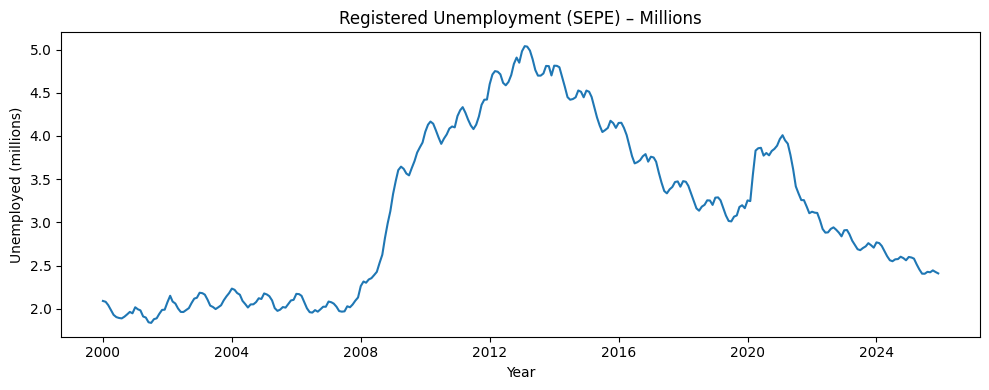

In [ ]:
# Plot unemployment series in millions
plt.figure(figsize=(10, 4))
plt.plot(unemploy_millions.index, unemploy_millions.values)
plt.title("Registered Unemployment (SEPE) – Millions")
plt.xlabel("Year")
plt.ylabel("Unemployed (millions)")
plt.tight_layout()
plt.show()


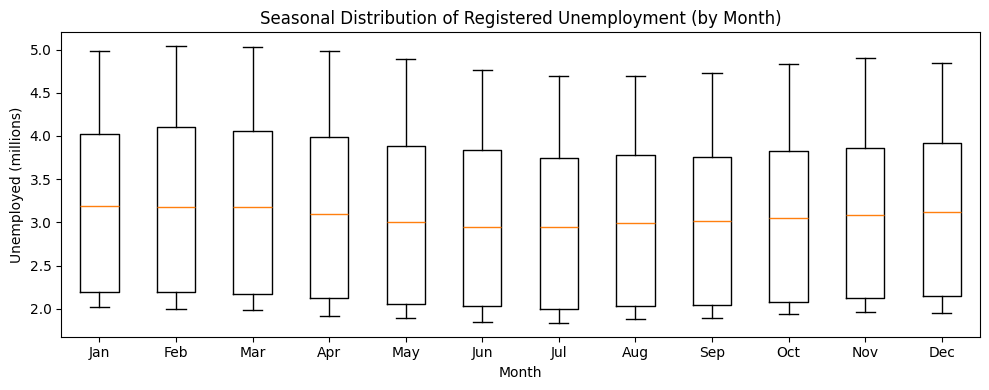

In [ ]:
# Prepare data: group by month ---
seasonal_df = pd.DataFrame({
    "unemployment": unemploy_millions.values,
    "month": unemploy_millions.index.month
})

monthly_groups = [
    seasonal_df.loc[seasonal_df["month"] == m, "unemployment"]
    for m in range(1, 13)
]

# --- Seasonal boxplot ---
plt.figure(figsize=(10, 4))
plt.boxplot(monthly_groups)
plt.xticks(
    ticks=range(1, 13),
    labels=["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"]
)
plt.title("Seasonal Distribution of Registered Unemployment (by Month)")
plt.xlabel("Month")
plt.ylabel("Unemployed (millions)")
plt.tight_layout()
plt.show()


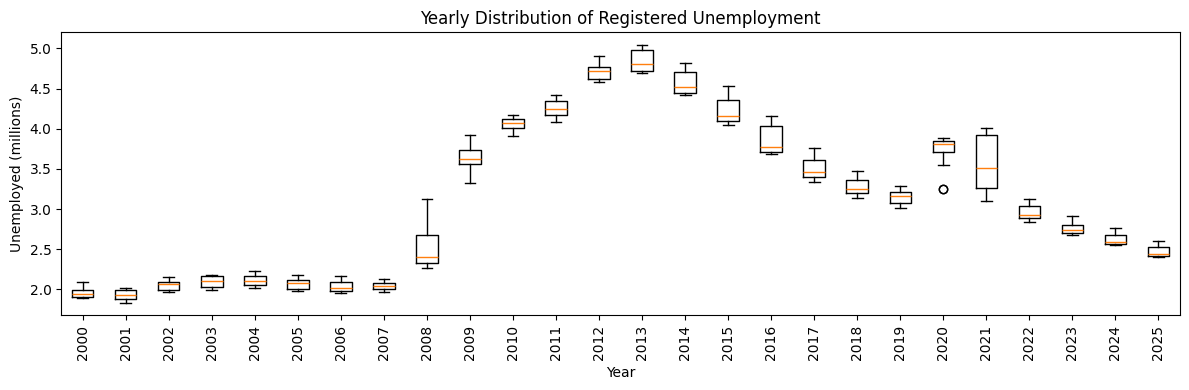

In [ ]:
# --- Prepare data: group by year ---
yearly_df = pd.DataFrame({
    "unemployment": unemploy_millions.values,
    "year": unemploy_millions.index.year
})

years = sorted(yearly_df["year"].unique())

yearly_groups = [
    yearly_df.loc[yearly_df["year"] == y, "unemployment"]
    for y in years
]

# --- Yearly boxplot ---
plt.figure(figsize=(12, 4))
plt.boxplot(yearly_groups)
plt.xticks(
    ticks=range(1, len(years) + 1),
    labels=years,
    rotation=90
)
plt.title("Yearly Distribution of Registered Unemployment")
plt.xlabel("Year")
plt.ylabel("Unemployed (millions)")
plt.tight_layout()
plt.show()


### Preliminar Analysis

Overall, the plots suggest a a time series with trend, seasonality, and structural breaks, implying that standard stationary models are unlikely to be appropriate without prior transformation or explicit modeling of these components.

First, the series displays a strong non-stationary behavior, characterized by pronounced long-run movements. In particular, there is a relatively stable period during the early 2000s, followed by a sharp and persistent increase starting around 2008, coinciding with the global financial crisis. Unemployment reaches a peak around 2012–2013, after which a gradual downward trend is observed until 2019. A new, abrupt increase appears in 2020, associated with the COVID-19 shock, followed by a sustained decline in the most recent years.

Second, the time series clearly exhibits seasonal fluctuations, visible as regular intra-year oscillations. This seasonal pattern is confirmed by the monthly boxplot, which shows systematic differences across months. Some months consistently present higher median unemployment levels than others, indicating the presence of a recurrent seasonal component that should be accounted for in any empirical analysis.

Finally, the yearly boxplot highlights substantial changes in variability over time. Periods associated with economic crises display higher unemployment levels and generally greater within-year dispersion, whereas more stable periods are characterized by lower variability.



<Figure size 1600x1600 with 0 Axes>

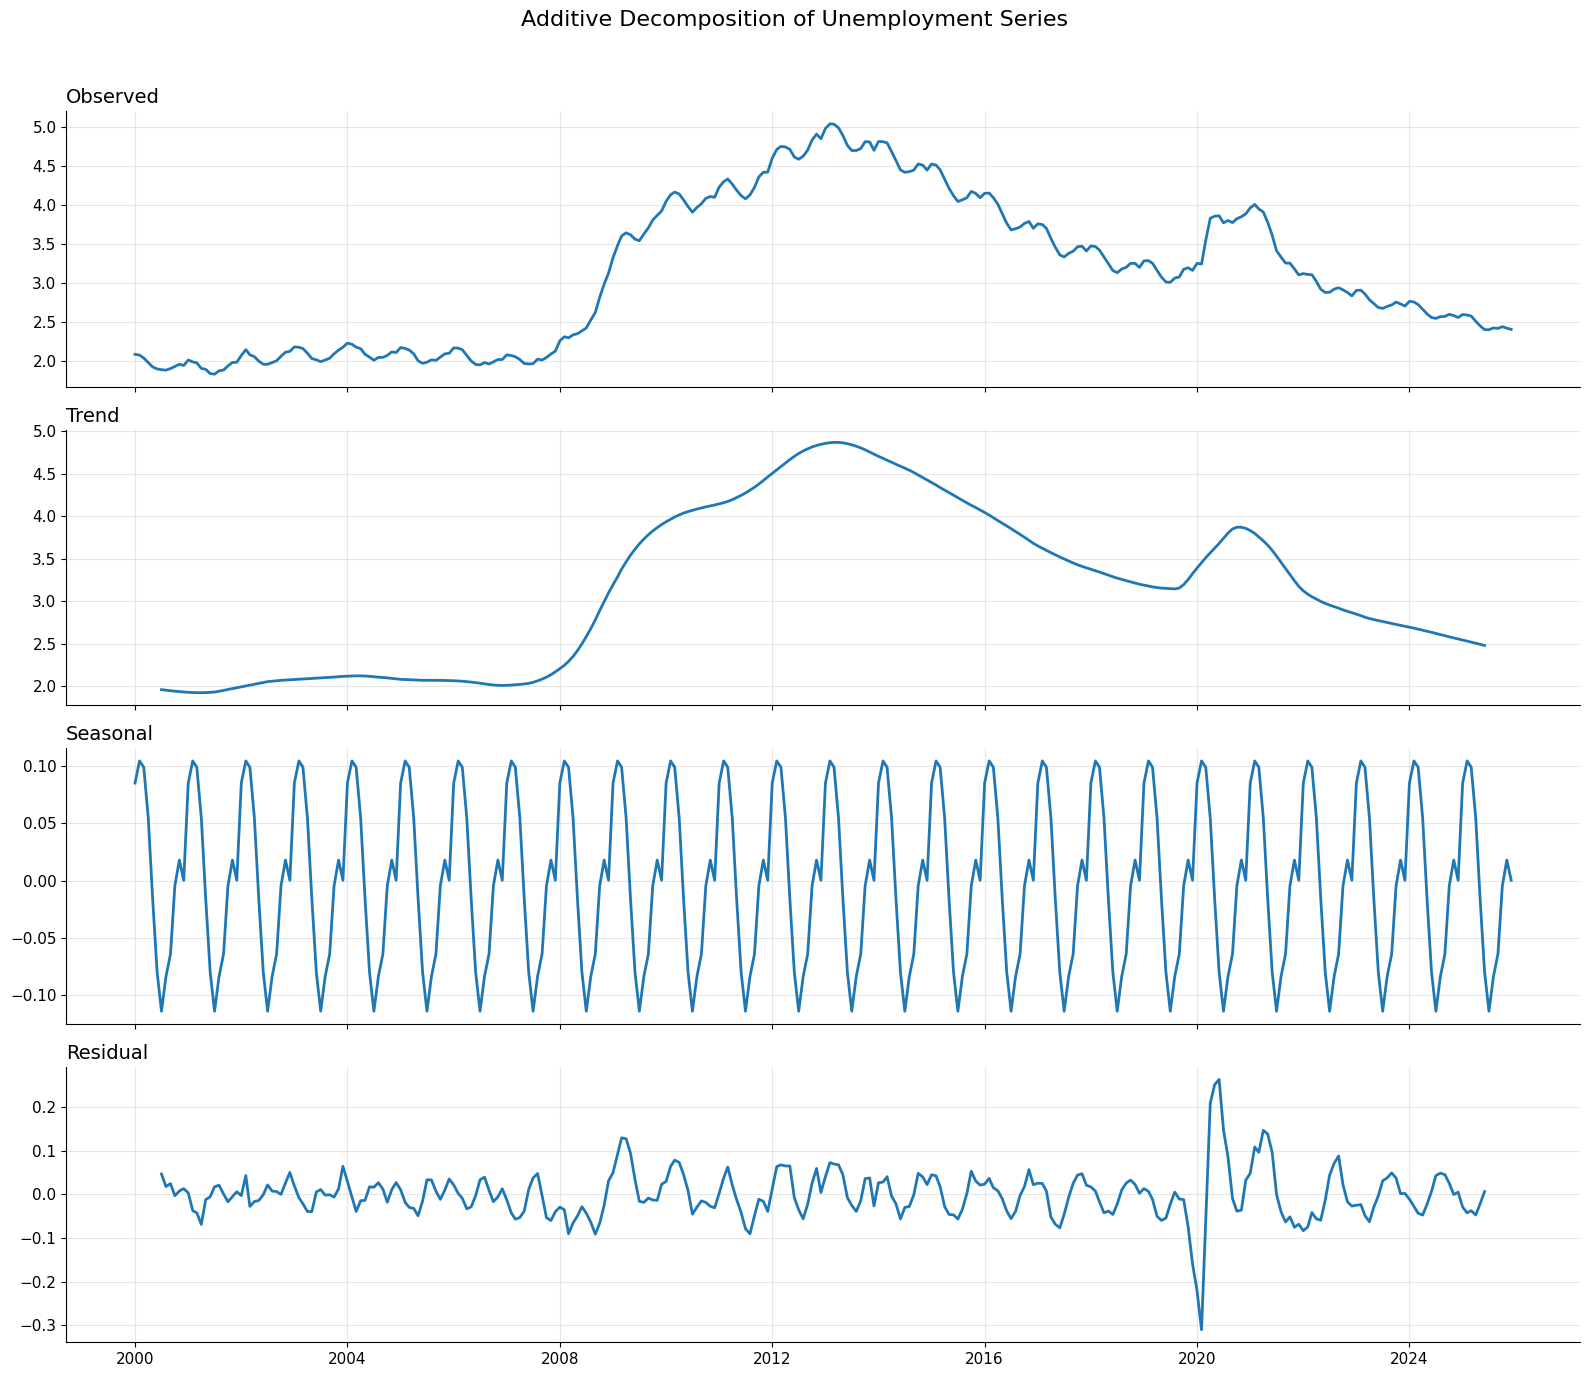

In [ ]:
plt.figure(figsize=(16, 16))
dc = seasonal_decompose(unemploy_millions, model="additive")
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# Observed
axes[0].plot(dc.observed, linewidth=2)
axes[0].set_title("Observed", fontsize=14, loc="left")

# Trend
axes[1].plot(dc.trend, linewidth=2)
axes[1].set_title("Trend", fontsize=14, loc="left")

# Seasonal
axes[2].plot(dc.seasonal, linewidth=2)
axes[2].set_title("Seasonal", fontsize=14, loc="left")

# Residual
axes[3].plot(dc.resid, linewidth=2)
axes[3].set_title("Residual", fontsize=14, loc="left")

# Global formatting
for ax in axes:
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Additive Decomposition of Unemployment Series",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
y = unemploy_millions.copy()

### Justification of the transformations

The original unemployment series in levels exhibits clear evidence of non-stationarity, as shown by pronounced long-run movements and persistent changes in the mean over time. In particular, the series displays strong upward and downward trends associated with major macroeconomic events, such as the 2008 global financial crisis and the Pandemic shock of 2020. As a result, modeling the series in levels would likely violate the assumption of constant mean required for covariance stationarity.

We apply a log transformation to the series to stabilize the scale of the series and mitigate potential heteroskedasticity. Moreover, the log transformation allows subsequent differences to be interpreted as approximate growth rates, which are often more stable over time.

Despite the log transformation, the series in log-levels still exhibits persistent dynamics, indicating the presence of a stochastic trend. Therefore, the first difference of the logarithm is taken to remove this trend component. This transformation eliminates low-frequency movements in the mean and yields a series centered around zero, consistent with the behavior of a stationary process.

In addition, the original series shows a clear and recurrent seasonal pattern at the monthly frequency. To account for this, a seasonal difference of order twelve is applied. Seasonal differencing removes systematic month-of-the-year effects that persist over time and are not eliminated by standard first differencing alone.

Finally, if residual seasonality remains after first differencing, the seasonal difference of the log-differenced series is considered. This combined transformation removes both the stochastic trend and seasonal dependence, yielding a series that is more plausibly stationary in both mean and variance.

Overall, the sequence of transformations — logarithmic scaling, first differencing, and seasonal differencing — is motivated by the presence of trend, seasonality, and changing variance in the original unemployment series, and is consistent with standard time-series practice for achieving stationarity prior to formal modeling.

In [ ]:
log_y = np.log(y).dropna()
log_y.name='log(Unemploy)'

dlog_y = log_y.diff(1).dropna()
dlog_y.name='dlog(Unemploy)'

d12_log_y = log_y.diff(12).dropna()
d12_log_y.name='d12log(Unemploy)'

d12_dlog_y = dlog_y.diff(12).dropna()
d12_dlog_y.name='d12dlog(Unemploy)'

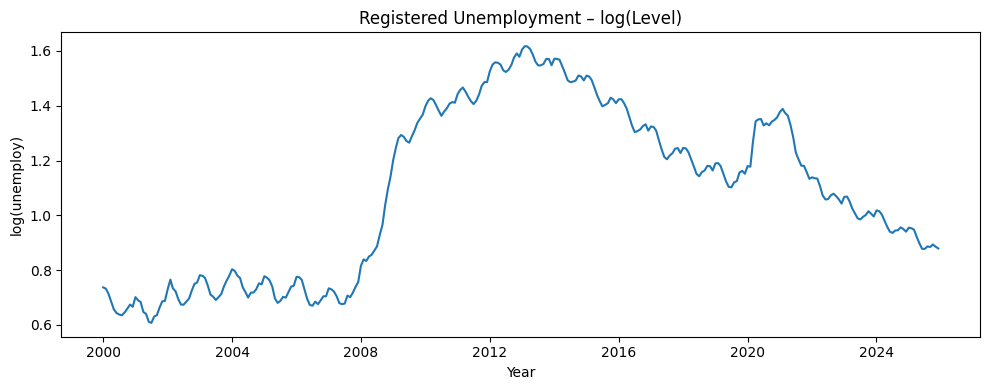

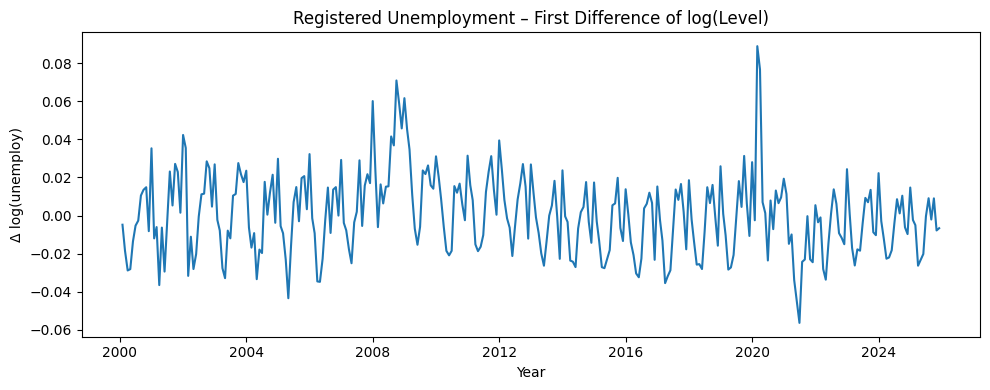

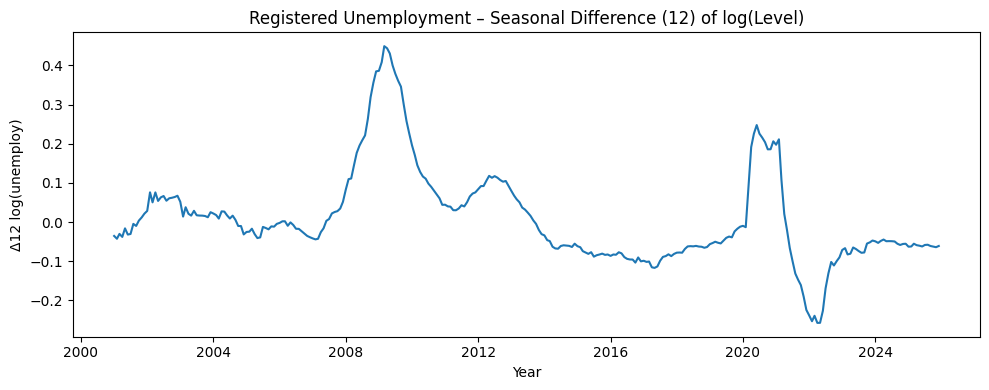

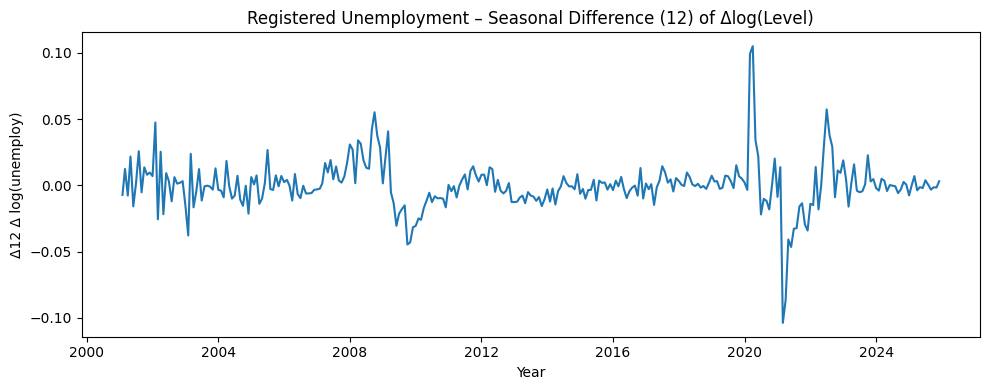

In [ ]:
# 1) Log-level
plt.figure(figsize=(10, 4))
plt.plot(log_y.index, log_y.values)
plt.title("Registered Unemployment – log(Level)")
plt.xlabel("Year")
plt.ylabel("log(unemploy)")
plt.tight_layout()
plt.show()

# 2) First difference of log
plt.figure(figsize=(10, 4))
plt.plot(dlog_y.index, dlog_y.values)
plt.title("Registered Unemployment – First Difference of log(Level)")
plt.xlabel("Year")
plt.ylabel("Δ log(unemploy)")
plt.tight_layout()
plt.show()

# 3) Seasonal difference (12) of log-level
plt.figure(figsize=(10, 4))
plt.plot(d12_log_y.index, d12_log_y.values)
plt.title("Registered Unemployment – Seasonal Difference (12) of log(Level)")
plt.xlabel("Year")
plt.ylabel("Δ12 log(unemploy)")
plt.tight_layout()
plt.show()

# 4) Seasonal difference (12) of Δlog (often used if seasonality remains)
plt.figure(figsize=(10, 4))
plt.plot(d12_dlog_y.index, d12_dlog_y.values)
plt.title("Registered Unemployment – Seasonal Difference (12) of Δlog(Level)")
plt.xlabel("Year")
plt.ylabel("Δ12 Δ log(unemploy)")
plt.tight_layout()
plt.show()


Taking the first difference of the logarithm substantially alters the behavior of the series. The transformed series fluctuates around zero and no longer exhibits a clear deterministic or stochastic trend. This indicates that first differencing is effective in removing the unit-root component present in the log series. However, the differenced log series still shows clear regular oscillations, reflecting the persistence of monthly seasonality.

To address this, a s**easonal difference of order 12 **is applied. Seasonal differencing of the log-level series removes systematic month-of-the-year effects, but the resulting series still displays slow-moving dynamics and large medium-term swings, especially around major crisis episodes. This suggests that seasonal differencing alone is insufficient to eliminate the non-stationary component.

Finally, applying a seasonal difference to the first difference of the log series removes both the stochastic trend and the seasonal pattern. The resulting series fluctuates around a stable mean, exhibits no visible trend, and shows a substantially more stable variance over time, except for short-lived spikes associated with extraordinary shocks such as the financial crisis and the COVID-19 period. These spikes are consistent with transitory shocks rather than persistent non-stationarity.

Overall, the graphical evidence supports the conclusion that the unemployment series is integrated and seasonally integrated. The combination of a logarithmic transformation, first differencing, and seasonal differencing is therefore appropriate to obtain a series that is plausibly stationary in both mean and variance and suitable for further time-series modeling.

### ACF and PACF analysis

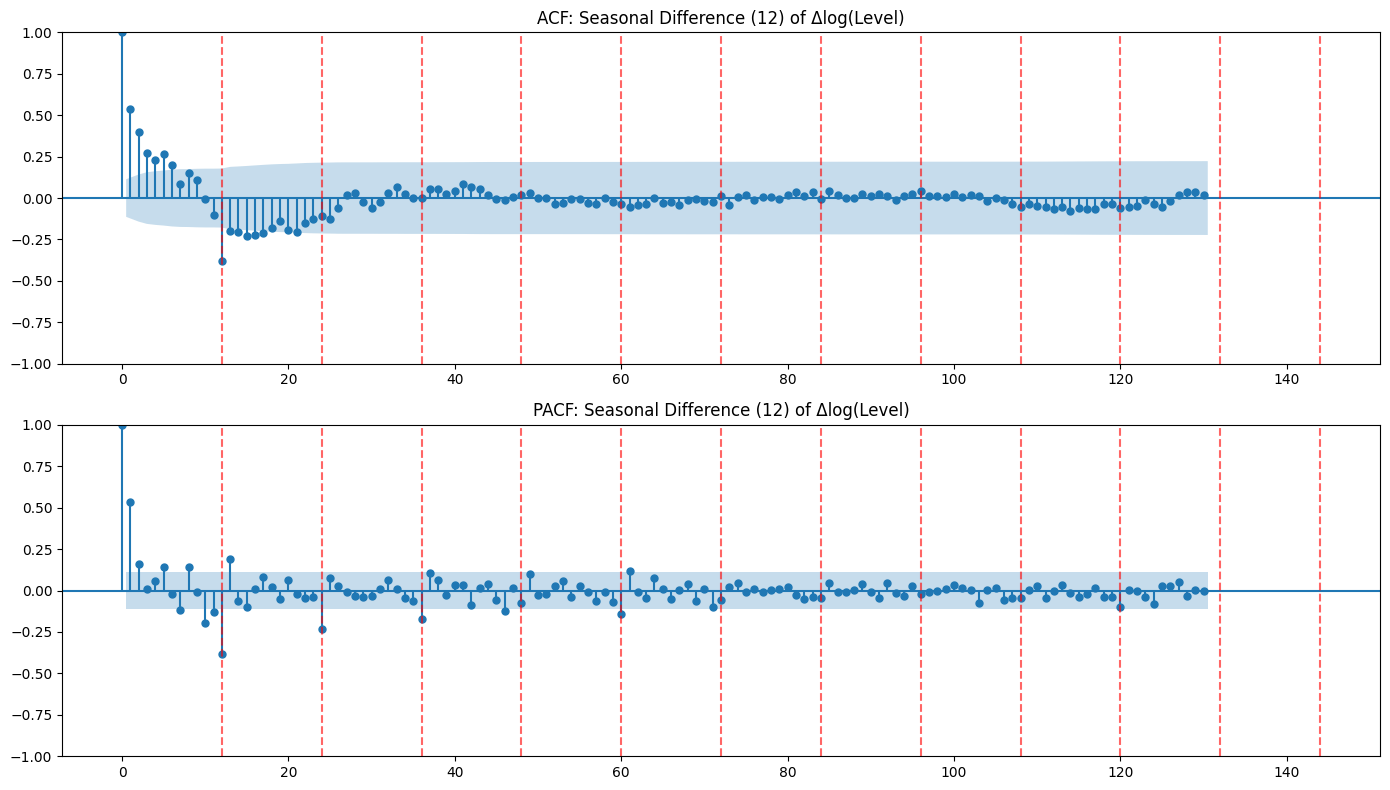

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# acf
plot_acf(d12_dlog_y, ax=axes[0], lags=130)
axes[0].set_title("ACF: Seasonal Difference (12) of Δlog(Level)")

# h
for k in range(12, 151, 12):
    axes[0].axvline(x=k, color="red", linestyle="--", alpha=0.6)

# pacf
plot_pacf(d12_dlog_y, ax=axes[1], lags=130, method="ywm")
axes[1].set_title("PACF: Seasonal Difference (12) of Δlog(Level)")

# h
for k in range(12, 151, 12):
    axes[1].axvline(x=k, color="red", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


What do we observe in each of the graphs?

**ACF:** very strong positive at lag 1, then a slow decay over several lags. It points to an AR component (not pure MA).

**PACF:** one huge spike at lag 1, and then most lags are inside bands again screams AR(1).

**Seasonal lags:** there is a clear negative spike at lag 12 in the PACF (and weaker echoes at multiples), which suggests a seasonal AR term may still be needed even after seasonal differencing.

## Model Proposal:

Based on the sample ACF and PACF of the transformed series $W_t= Δ12 Δlog(X_t)$, the autocorrelation structure points  toward autoregressive dynamics rather than a pure moving-average specification.
The ACF exhibits a large positive correlation at lag 1 followed by a gradual decay, while the PACF shows a dominant and statistically significant spike at lag 1 with most higher-order lags lying within the confidence bands. This pattern is characteristic of an AR(1) process and suggests that short-run persistence in the series can be parsimoniously captured by a first-order autoregressive term.

In addition, the PACF displays a noticeable negative spike at lag 12, indicating that some seasonal short-memory dependence remains even after seasonal differencing. This motivates extending the baseline ARIMA(1,1,O) model to include a seasonal autoregressive term at lag 12, i.e a

As a more flexible alternative, an ARIMA(1,1,1) specification can also be considered, allowing for richer short-run dynamics when the decay in the ACF is not perfectly captured by a pure AR structure.

## Estimation of proposed models

We believe that together, $ARIMA(1,1,0)$, $SARIMA(1,1,0)(1,1,0)_{(12)}$ or SAR(1), and $ARIMA(1,1,1)$ form a coherent and theoretically consistent set of candidate models for the transformed series. We proceed to fit the models and evaluate the significance of their coefficientes.

In terms on notation in the code, it is important to note that we previously applied a log transformation, a non-seasonal difference, and a seasonal difference manually to achieve stationarity. In the orders of the following models, we don't need to apply this transformations again.


In [ ]:
x = d12_dlog_y.dropna().copy()

In [ ]:
def fit_and_check(x, order=(1,0,0), seasonal_order=(0,0,0,12), name="Model", max_lag_acf=48):
    model = SARIMAX(
        x,
        order=order,
        seasonal_order=seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)

    print("="*80)
    print(f"{name}: order={order}, seasonal_order={seasonal_order}")
    print(res.summary())

    # significance tabl
    pvals = res.pvalues
    params = res.params
    sig_table = pd.DataFrame({"coef": params, "pvalue": pvals})
    print("\nSignificance (p-values):")
    print(sig_table)


    return res, sig_table

In [ ]:
# ARIMA(1,1,0)
res_ar1, sig_ar1 = fit_and_check(
    x,
    order=(1,0,0),
    seasonal_order=(0,0,0,12),
    name="A) ARIMA(1,1,0)",
    max_lag_acf=60
)


A) ARIMA(1,1,0): order=(1, 0, 0), seasonal_order=(0, 0, 0, 12)
                               SARIMAX Results                                
Dep. Variable:      d12dlog(Unemploy)   No. Observations:                  299
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 813.591
Date:                Sun, 22 Feb 2026   AIC                          -1623.182
Time:                        14:23:24   BIC                          -1615.788
Sample:                    02-01-2001   HQIC                         -1620.223
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5352      0.030     17.889      0.000       0.477       0.594
sigma2         0.0002   7.36e-06     33.841      0.000       0.000  

In [ ]:
# # SARIMA(1,1,0)(1,1,0) [12]
res_ar1_sar1, sig_ar1_sar1 = fit_and_check(
    x,
    order=(1,0,0), # We set the order d=0 because we applied the regular difference manually to achieve stationartiy before fitting the model.
    seasonal_order=(1,0,0,12),
    name="B) SARIMA(1,1,0)(1,1,0) [12]",
    max_lag_acf=60
)

B) SARIMA(1,1,0)(1,1,0) [12]: order=(1, 0, 0), seasonal_order=(1, 0, 0, 12)
                                     SARIMAX Results                                      
Dep. Variable:                  d12dlog(Unemploy)   No. Observations:                  299
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                 822.085
Date:                            Sun, 22 Feb 2026   AIC                          -1638.171
Time:                                    14:23:25   BIC                          -1627.203
Sample:                                02-01-2001   HQIC                         -1633.774
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6088      0.028     2

In [ ]:
#ARIMA(1,1,1)
res_arma11, sig_arma11 = fit_and_check(
    x,
    order=(1,0,1),
    seasonal_order=(0,0,0,12),
    name="C) ARIMA(1,1,1) on x_t",
    max_lag_acf=60
)

C) ARIMA(1,1,1) on x_t: order=(1, 0, 1), seasonal_order=(0, 0, 0, 12)
                               SARIMAX Results                                
Dep. Variable:      d12dlog(Unemploy)   No. Observations:                  299
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 814.583
Date:                Sun, 22 Feb 2026   AIC                          -1623.165
Time:                        14:23:25   BIC                          -1612.084
Sample:                    02-01-2001   HQIC                         -1618.729
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7306      0.064     11.406      0.000       0.605       0.856
ma.L1         -0.2774      0.071     -3.917      0.000      -

### Cofficients Significance

In the **ARIMA(1,1,0)** model, the autoregressive coefficient is positive and highly significant, indicating substantial short-run persistence in the series. The Ljung–Box test at lag 1 does not reject the null of no residual autocorrelation, indicating the residuals are compatible with white noise at short horizons. However, this model does not explicitly account for the remaining seasonal dependence observed in the correlograms.

The **SARIMA(1,1,0)(1,1,0)** model, yields a clear improvement. Both the non-seasonal AR(1) coefficient and the seasonal SAR(12) coefficient are highly statistically significant. The negative sign of  the seasonal coefficient, is consistent with the pattern observed in the PACF at lag 12.
The Ljung–Box test strongly supports the absence of residual autocorrelation, and the model achieves the lowest AIC among the candidates. Since all coefficients are statistically significant, no further simplification is required.

Finally, the **ARIMA(1,1,1)** evaluation supports that  AR(1) and MA(1) coefficients are statistically significant, while residual autocorrelation is not detected according to the Ljung–Box statistic. It it important to note this model does not capture the seasonal dependence explicitly.

## Residual analysis & calculation of the metrics or comparisons

Residual dependence analysis checks whether our model has successfully captured all the time-based patterns (the "memory") in the data.

If our models are correctly specificified.the residuals should behave like an independent and identically distributed (iid) white noise sequence.


### Evaluating Causality and Invertibility

In [ ]:
def _poly_from_lag_coefs(lag_to_coef, kind="AR"):
    """
    Build polynomial in z = L (lag operator).
    AR:  1 - Σ phi_k z^k
    MA:  1 + Σ theta_k z^k
    Returns coefficients in descending powers for np.roots.
    """
    if not lag_to_coef:
        return np.array([1.0])  # polynomial = 1

    max_lag = max(lag_to_coef.keys())
    coefs_asc = np.zeros(max_lag + 1, dtype=float)
    coefs_asc[0] = 1.0

    for lag, c in lag_to_coef.items():
        if kind.upper() == "AR":
            coefs_asc[lag] = -float(c)
        elif kind.upper() == "MA":
            coefs_asc[lag] = +float(c)
        else:
            raise ValueError("kind must be 'AR' or 'MA'")

    return coefs_asc[::-1]  # descending for np.roots


def _multiply_polys_desc(p_desc, q_desc):
    """Multiply two polynomials given in descending power order."""
    p_asc = p_desc[::-1]
    q_asc = q_desc[::-1]
    prod_asc = np.convolve(p_asc, q_asc)
    return prod_asc[::-1]


def characteristic_roots(res):
    """
    Compute roots (and moduli) of the full AR and MA characteristic polynomials,
    including seasonal components, from a fitted statsmodels SARIMAXResults `res`.

    Causality: all AR roots have |root| > 1
    Invertibility: all MA roots have |root| > 1
    """
    s = getattr(res.model, "seasonal_periods", 0) or 0

    # Extract coefficients by name
    params = res.params.to_dict() if hasattr(res.params, "to_dict") else dict(res.params)

    ar_lags = {}
    sar_lags = {}
    ma_lags = {}
    sma_lags = {}

    for name, val in params.items():
        if name.startswith("ar.L"):
            lag = int(name.split("ar.L")[1])
            ar_lags[lag] = val
        elif name.startswith("ar.S.L"):
            lag = int(name.split("ar.S.L")[1])
            sar_lags[lag] = val  # lag is already absolute (e.g., 12, 24, ...)
        elif name.startswith("ma.L"):
            lag = int(name.split("ma.L")[1])
            ma_lags[lag] = val
        elif name.startswith("ma.S.L"):
            lag = int(name.split("ma.S.L")[1])
            sma_lags[lag] = val

    # Build non-seasonal and seasonal polynomials separately, then multiply
    ar_poly = _poly_from_lag_coefs(ar_lags, kind="AR")
    sar_poly = _poly_from_lag_coefs(sar_lags, kind="AR")
    full_ar_poly = _multiply_polys_desc(ar_poly, sar_poly)

    ma_poly = _poly_from_lag_coefs(ma_lags, kind="MA")
    sma_poly = _poly_from_lag_coefs(sma_lags, kind="MA")
    full_ma_poly = _multiply_polys_desc(ma_poly, sma_poly)

    # Roots
    ar_roots = np.roots(full_ar_poly) if len(full_ar_poly) > 1 else np.array([])
    ma_roots = np.roots(full_ma_poly) if len(full_ma_poly) > 1 else np.array([])

    ar_mod = np.abs(ar_roots)
    ma_mod = np.abs(ma_roots)

    causal = True if ar_roots.size == 0 else np.all(ar_mod > 1.0)
    invertible = True if ma_roots.size == 0 else np.all(ma_mod > 1.0)

    return {
        "AR_poly_desc": full_ar_poly,
        "MA_poly_desc": full_ma_poly,
        "AR_roots": ar_roots,
        "MA_roots": ma_roots,
        "AR_modulus": ar_mod,
        "MA_modulus": ma_mod,
        "is_causal": causal,
        "is_invertible": invertible,
    }


In [ ]:
out_A = characteristic_roots(res_ar1)
out_B = characteristic_roots(res_ar1_sar1)
out_C = characteristic_roots(res_arma11)

def print_root_check(label, out):
    print(f"\n--- {label} ---")
    if out["AR_roots"].size:
        print("AR roots moduli:", np.round(out["AR_modulus"], 4))
    else:
        print("AR part: none (trivially causal)")
    if out["MA_roots"].size:
        print("MA roots moduli:", np.round(out["MA_modulus"], 4))
    else:
        print("MA part: none (trivially invertible)")
    print("Causal?      ", out["is_causal"])
    print("Invertible?  ", out["is_invertible"])

print_root_check("A) AR(1)", out_A)
print_root_check("B) AR(1) + seasonal AR(12)", out_B)
print_root_check("C) ARMA(1,1)", out_C)



--- A) AR(1) ---
AR roots moduli: [1.8684]
MA part: none (trivially invertible)
Causal?       True
Invertible?   True

--- B) AR(1) + seasonal AR(12) ---
AR roots moduli: [1.0662 1.0662 1.0662 1.0662 1.0662 1.0662 1.6426 1.0662 1.0662 1.0662
 1.0662 1.0662 1.0662]
MA part: none (trivially invertible)
Causal?       True
Invertible?   True

--- C) ARMA(1,1) ---
AR roots moduli: [1.3688]
MA roots moduli: [3.6055]
Causal?       True
Invertible?   True


 **Conclussion**: All the roots yield the necessary results to claim that our three models are causal and invertible.

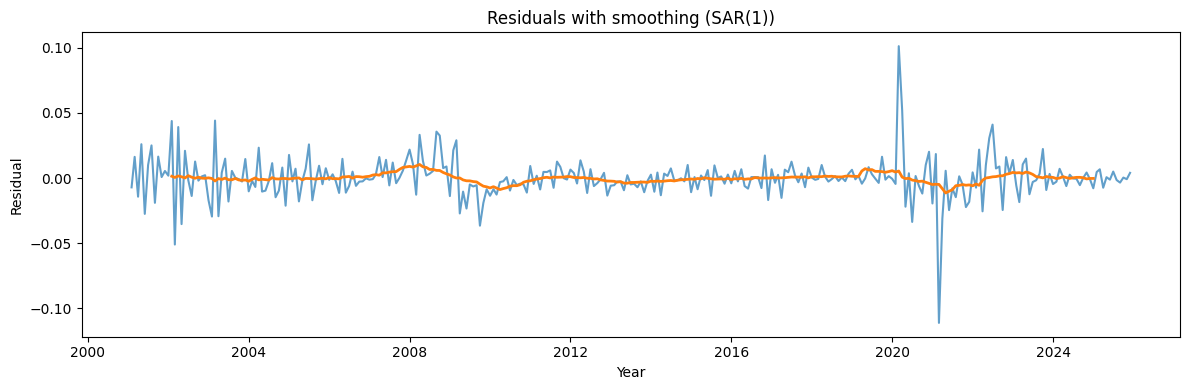

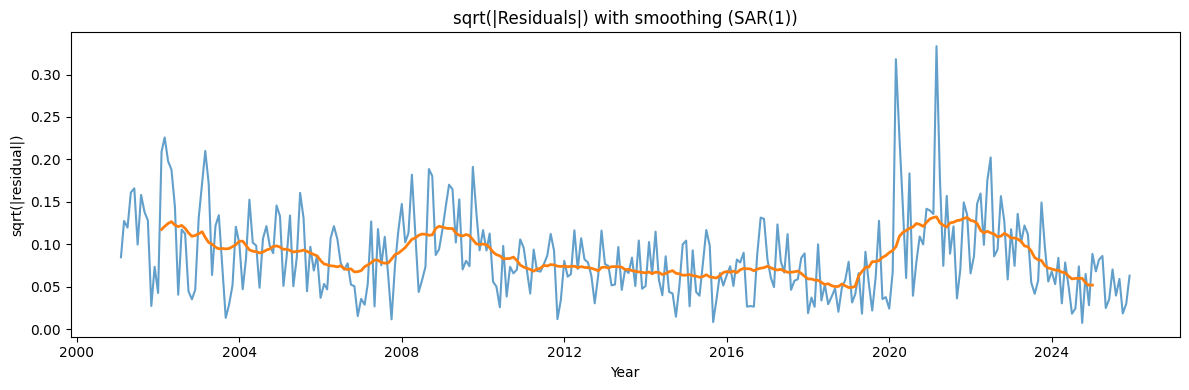

In [ ]:
def plot_resid_vol(res, label, win=24):
    idx = getattr(res.model.data, "row_labels", None)
    resid = pd.Series(res.resid, index=idx).dropna() if idx is not None else pd.Series(res.resid).dropna()

    sqabs_resid = np.sqrt(np.abs(resid))

    resid_smooth = resid.rolling(win, center=True).mean()
    sqabs_smooth = sqabs_resid.rolling(win, center=True).mean()


    plt.figure(figsize=(12, 4))
    plt.plot(resid.index, resid.values, alpha=0.7)
    plt.plot(resid_smooth.index, resid_smooth.values, linewidth=2)
    plt.title(f"Residuals with smoothing ({label})")
    plt.xlabel("Year")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

    #
    plt.figure(figsize=(12, 4))
    plt.plot(sqabs_resid.index, sqabs_resid.values, alpha=0.7)
    plt.plot(sqabs_smooth.index, sqabs_smooth.values, linewidth=2)
    plt.title(f"sqrt(|Residuals|) with smoothing ({label})")
    plt.xlabel("Year")
    plt.ylabel("sqrt(|residual|)")
    plt.tight_layout()
    plt.show()

plot_resid_vol(res_ar1, "SAR(1)") # Equivalent to SARIMA(1,1,0)(1,1,0)


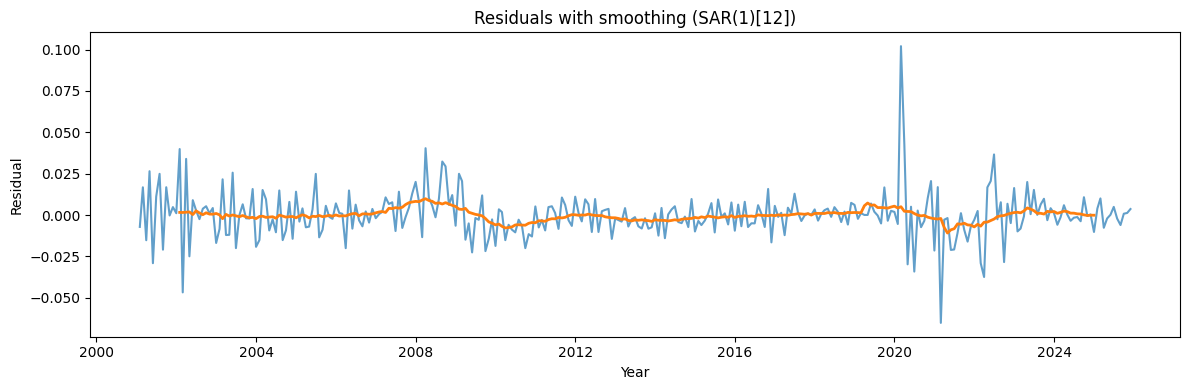

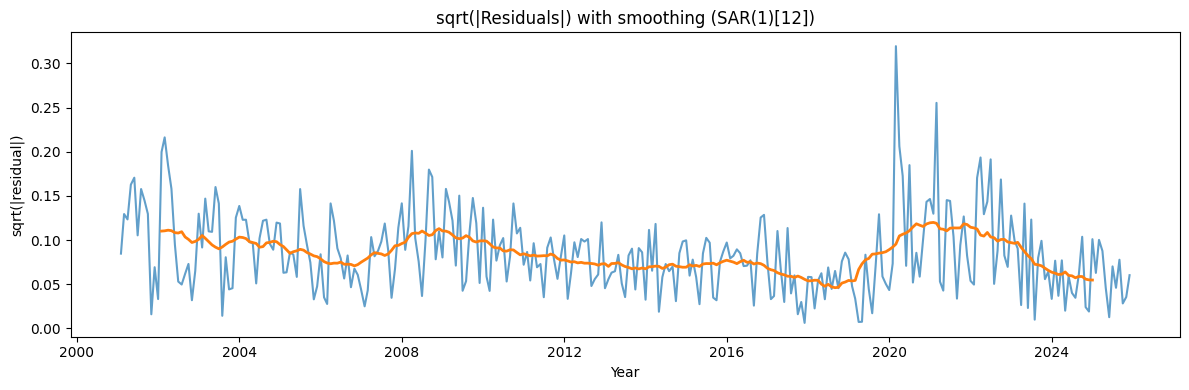

In [ ]:
plot_resid_vol(res_ar1_sar1, "SAR(1)[12]")


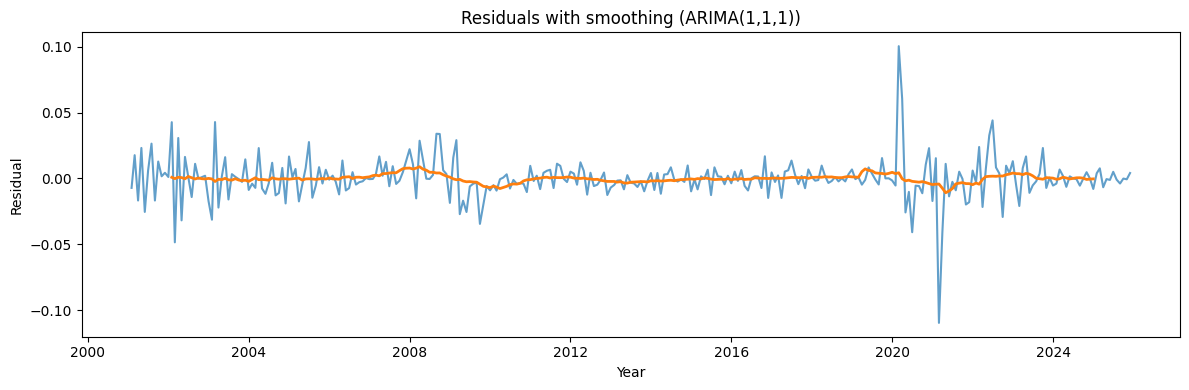

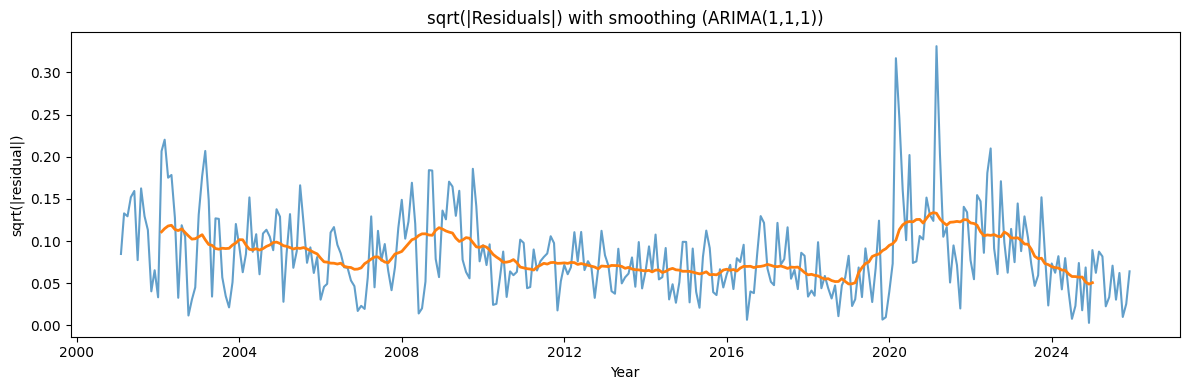

In [ ]:
plot_resid_vol(res_arma11, "ARIMA(1,1,1)")


### Homoscedasticity validation
Based on the residual plots and the smoothed series of $\sqrt(|e_t|)$, the assumption of constant variance is not fully supported. While the residuals themselves fluctuate around zero with no persistent mean shifts, **the magnitude of the residuals clearly varies over time.** This is visible in the smoothed $\sqrt(|e_t|)$ series, which shows pronounced medium-term changes rather than remaining approximately flat.

All three models exhibit periods of elevated residual dispersion, most notably around the global financial crisis and the pandemics period. These episodes are characterized by sustained increases in the smoothed $\sqrt(|e_t|)$, followed by gradual declines, which is inconsistent with homoskedastic errors. Although the SARIMA(1,1,0)(1,1,0)[12] specification reduces some of the short-run volatility relative to the simpler ARIMA(1,1,0) model, the overall pattern of time-varying dispersion remains.

Therefore, based on visual inspection of the residuals and their smoothed absolute magnitudes, it is not reasonable to assume constant variance over the full sample. The plots suggest the presence of volatility clustering or regime-dependent variance, motivating further analysis of heteroskedasticity in subsequent steps.

In [ ]:
def normal_check(res, label, bins=30):
  idx=getattr(res.model.data, 'row_labels', None)
  resid = pd.Series(res.resid, index=idx).dropna() if idx is not None else pd.Series(res.resid).dropna()

  plt.figure(figsize=(12, 4))
  stats.probplot(resid, dist="norm", plot=plt)
  plt.title(f'Normal Q-Q plot of residuals ({label})')
  plt.tight_layout()
  plt.show()

  mu, sigma = resid.mean(), resid.std(ddof=1)
  x = np.linspace(resid.min(), resid.max(), 250)
  normal_pdf = stats.norm.pdf(x, mu, sigma)

  plt.figure(figsize = (8, 4))
  plt.hist(resid, bins=bins, density=True, alpha=0.6, color='g')
  plt.plot(x, normal_pdf, linewidth = 2)
  plt.title(f'Histogram of residuals ({label})')
  plt.xlabel('Residuals')
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()

  W, p = stats.shapiro (resid)
  print(f'\n{label} | Shapiro-Wilk test: W = {W:.4f}, p-value = {p:.4f}')

  return {"model": label, "W": W, "p-value": p, 'nobs': resid.shape[0]}

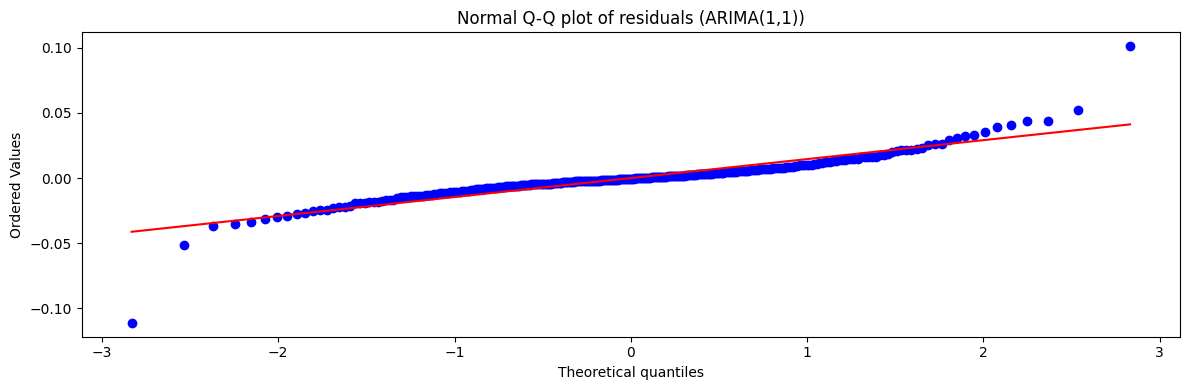

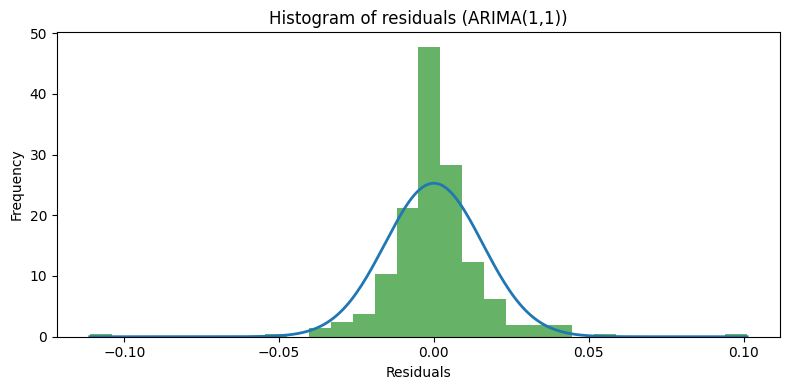


ARIMA(1,1) | Shapiro-Wilk test: W = 0.8520, p-value = 0.0000


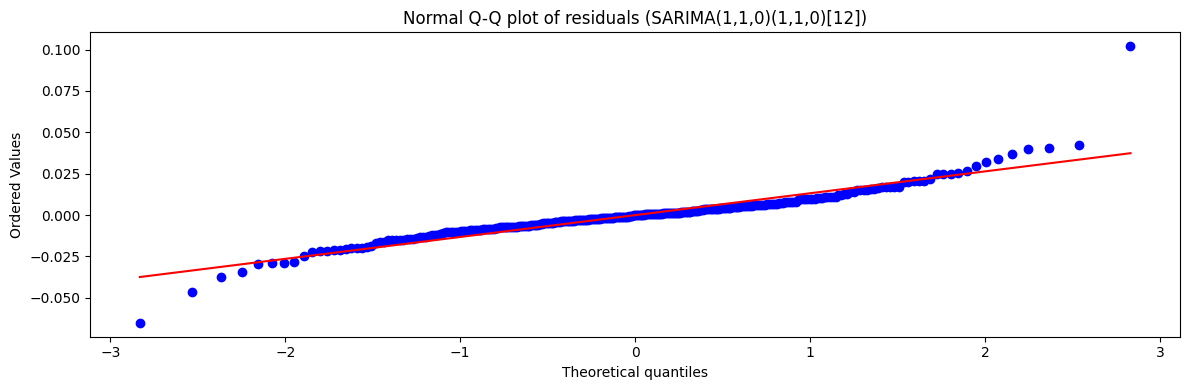

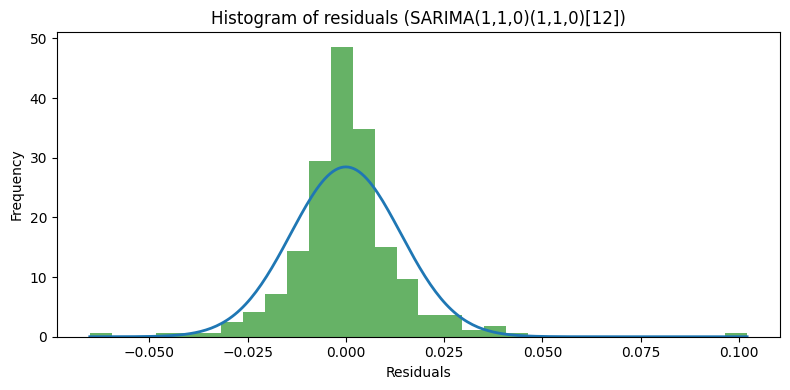


SARIMA(1,1,0)(1,1,0)[12] | Shapiro-Wilk test: W = 0.8887, p-value = 0.0000


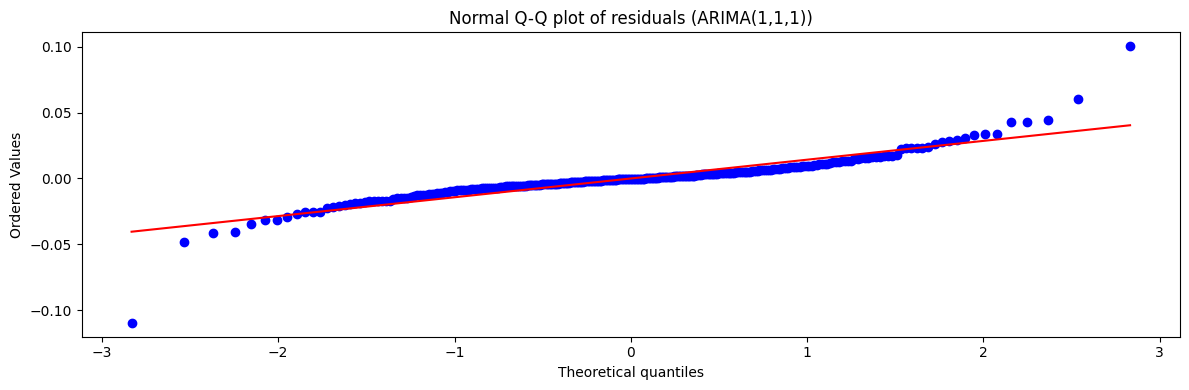

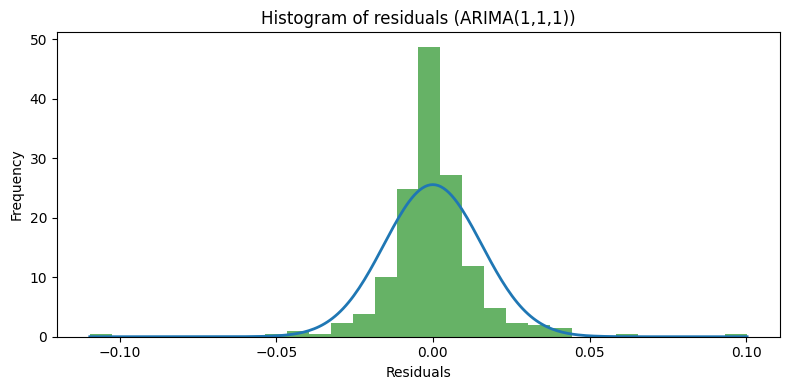


ARIMA(1,1,1) | Shapiro-Wilk test: W = 0.8385, p-value = 0.0000


In [ ]:
models = [
    ('ARIMA(1,1)', res_ar1),
    ('SARIMA(1,1,0)(1,1,0)[12]', res_ar1_sar1),
    ('ARIMA(1,1,1)', res_arma11)
]

results = []
for label, res in models:
  results.append(normal_check(res, label))


### Normality Assumption

The Shapiro–Wilk test strongly rejects the null hypothesis of normally distributed residuals for all three models, with p-values effectively equal to zero. This conclusion confirms further the graphical diagnostics, which show clear departures from normality in the tails of the residual distribution.

It is very common for macro-economic data (like unemployment) to fail the Shapiro-Wilk test for normality, since Unemployment time series are prone to massive, sudden shocks (like the 2008 financial crisis or the 2020 COVID-19 pandemic). These shocks create  "fat tails" or large outliers in our residuals that a normal bell curve doesn't expect.

In [ ]:
def residual_independence(res, label, max_lag =48):
  idx = getattr(res.model.data, 'row_labels', None)
  resid = pd.Series(res.resid, index=idx).dropna() if idx is not None else pd.Series(res.resid).dropna()

  plt.figure(figsize=(10, 3.5))
  plot_acf(resid, lags=max_lag)
  plt.title(f"Residual ACF (white noise): {label}")
  plt.tight_layout()
  plt.show

  plt.figure(figsize=(10, 3.5))
  plot_pacf(resid, lags = max_lag)
  plt.title(f"Residual PACF (white noise): {label}")
  plt.tight_layout()
  plt.show

  lb = acorr_ljungbox(resid, lags=[12, 24, 36, 48], return_df=True)


  print(f'\nLjung-Box test p values({label}):')
  print(lb[['lb_stat', 'lb_pvalue']])

  return lb




Ljung-Box test p values(ARIMA(1,1,0)):
       lb_stat     lb_pvalue
12   95.900452  3.523380e-15
24  114.479611  9.229015e-14
36  124.954954  9.487965e-12
48  129.424588  2.096051e-09

Ljung-Box test p values(SARIMA(1,1,0)(1,10)[12]):
      lb_stat  lb_pvalue
12  32.732322   0.001066
24  66.154593   0.000008
36  77.602792   0.000070
48  82.557826   0.001418

Ljung-Box test p values(ARIMA(1,1,1)):
       lb_stat     lb_pvalue
12   88.358546  1.025466e-13
24  100.408931  2.558465e-11
36  115.922004  2.493185e-10
48  121.376810  2.771620e-08


<Figure size 1000x350 with 0 Axes>

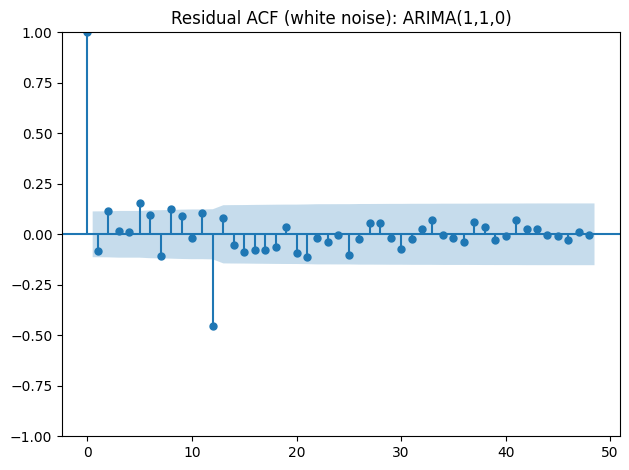

<Figure size 1000x350 with 0 Axes>

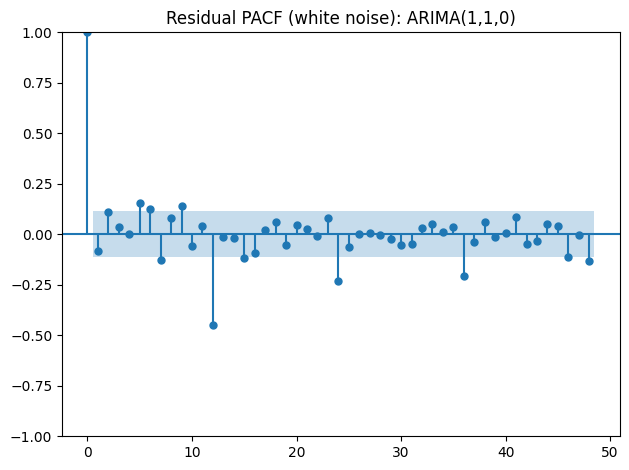

<Figure size 1000x350 with 0 Axes>

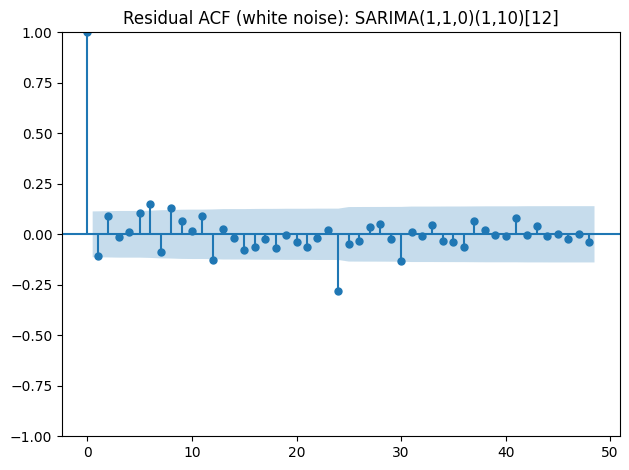

<Figure size 1000x350 with 0 Axes>

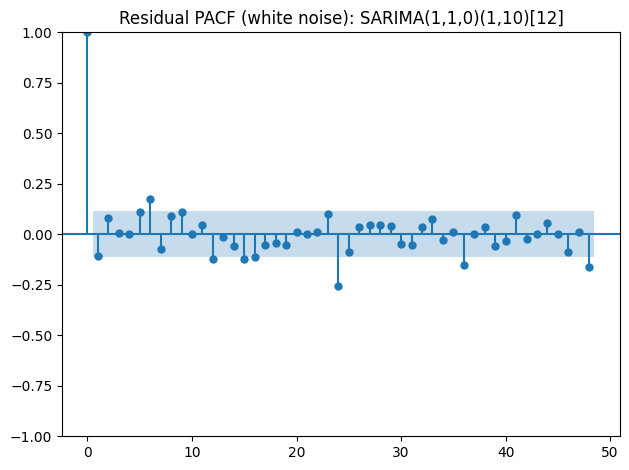

<Figure size 1000x350 with 0 Axes>

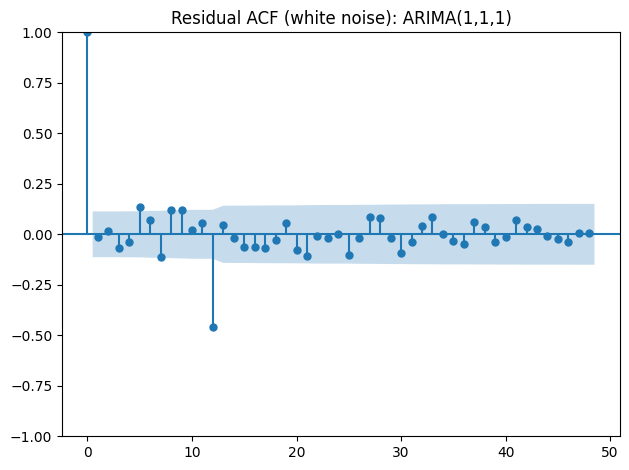

<Figure size 1000x350 with 0 Axes>

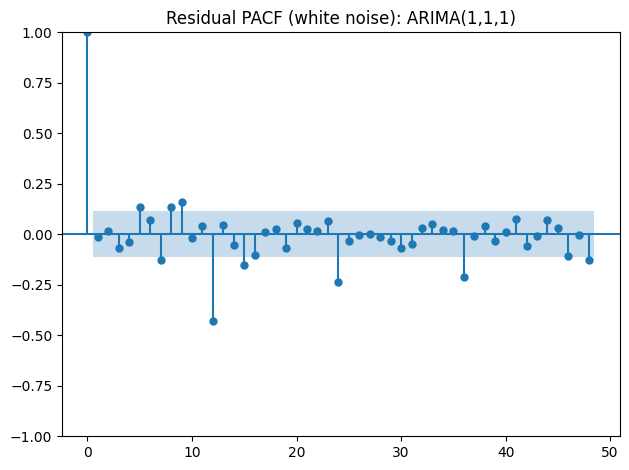

In [ ]:
models = [
    ('ARIMA(1,1,0)', res_ar1),
    ('SARIMA(1,1,0)(1,10)[12]', res_ar1_sar1),
    ('ARIMA(1,1,1)', res_arma11)
]

for label, res in models:
  residual_independence(res, label)

### Residual independence

At first glance, the residual ACF and PACF plots for all three models appear mostly well behaved with only the first lag being clearly significant and most other lags lying within the confidence bands. However the Ljung–Box test results provide **strong evidence against residual independence in all cases.**

For each specification, the Ljung–Box **p-values are extremely small at multiple horizons** (12, 24, 36, and 48), leading to a clear rejection of the null hypothesis of no serial correlation.

Looking more closely at the correlograms, this rejection is driven by systematic residual correlation at seasonal multiples, rather than by widespread short-run dependence. In the AR(1) model, there is clear residual seasonality, with significant negative autocorrelation at lag 12 in the ACF and at lags 12, 24, and 48 in the PACF. This indicates that the simple AR(1) specification fails to capture remaining seasonal dynamics.

The **SARIMA(1,1,0)(1,1,0)[12]** model substantially reduces this problem, but residual dependence remains at longer seasonal horizons, particularly at lags 24, 36, and 48. Finally, the **ARIMA(1,1,1)** model also exhibits residual correlation at seasonal multiples in the PACF, despite appearing clean at non-seasonal lags.

Overall, although residuals look approximately uncorrelated at short lags, the consistent rejection of the Ljung–Box test and the presence of significant negative correlations at seasonal multiples imply they cannot be assumed to be independent for any of the three models, the remaining dependence is structured and seasonal in nature.

## Goodness of fit AIC and BIC

In [ ]:
# Collect AIC and BIC for the three models
fit_measures = pd.DataFrame({
    "Model": [
        "ARIMA(1,1,0)",
        "SARIMA(1,1,0)(1,1,0)",
        "ARIMA(1,1,1)"
    ],
    "AIC": [
        res_ar1.aic,
        res_ar1_sar1.aic,
        res_arma11.aic
    ],
    "BIC": [
        res_ar1.bic,
        res_ar1_sar1.bic,
        res_arma11.bic
    ]
})

print("\nModel fit measures (lower is better):")
print(fit_measures.to_string(index=False))




Model fit measures (lower is better):
               Model          AIC          BIC
        ARIMA(1,1,0) -1623.182461 -1615.788274
SARIMA(1,1,0)(1,1,0) -1638.170788 -1627.202812
        ARIMA(1,1,1) -1623.165436 -1612.084239


Based on the information criteria, the seasonal specification clearly performs best. SARIMA(1,1,0)×(1,1,0)[12] achieves the lowest AIC (−1638.17) and BIC (−1627.20), indicating a better fit even after accounting for model complexity. In contrast, the nonseasonal ARIMA(1,1,0) and ARIMA(1,1,1) deliver very similar AIC values (around −1623), with only minor differences in BIC, suggesting that adding a nonseasonal MA(1) term does not materially improve the model. Overall, these results support including a seasonal AR component (with yearly period 12) as it provides a meaningful improvement in goodness-of-fit.

In [ ]:
x_full = d12_dlog_y.copy().dropna()
x_trunced = x_full.iloc[:-12]

def fit_models(series):
  results ={}

  results['ARIMA(1,1,0)'] = SARIMAX(
      series,
      order = (1,0,0),
      seasonal_order=(0,0,0,12),
      trend="n",
      enforce_stationarity=False,
      enforce_invertibility=False
  ).fit(disp=False)

  results['SARIMA(1,1,0)(1,1,0)[12]'] = SARIMAX(
      series,
      order = (1,0,0),
      seasonal_order=(1,0,0,12),
      trend="n",
      enforce_stationarity=False,
      enforce_invertibility=False
  ).fit(disp=False)

  results['ARIMA(1,1,1)'] = SARIMAX(
      series,
      order= (1,0,1),
      seasonal_order=(0,0,0,12),
      trend="n",
      enforce_stationarity=False,
      enforce_invertibility=False
  ).fit(disp=False)

  return results

In [ ]:
results_full = fit_models(x_full)
results_trunc = fit_models(x_trunced)

In [ ]:
rows =[]
for model in results_full.keys():
  rows.append({
      "Model": model,
      "Sample": "Full",
      "AIC": results_full[model].aic,
      "BIC": results_full[model].bic
  })
  rows.append({
      "Model": model,
      "Sample": "Excluding last 12",
      "AIC": results_trunc[model].aic,
      "BIC": results_trunc[model].bic
  })

fit_comparison = pd.DataFrame(rows)
fit_comparison


,Model,Sample,AIC,BIC
0,"ARIMA(1,1,0)",Full,-1623.182461,-1615.788274
1,"ARIMA(1,1,0)",Excluding last 12,-1546.834769,-1539.522786
2,"SARIMA(1,1,0)(1,1,0)[12]",Full,-1638.170788,-1627.202812
3,"SARIMA(1,1,0)(1,1,0)[12]",Excluding last 12,-1559.325276,-1548.485891
4,"ARIMA(1,1,1)",Full,-1623.165436,-1612.084239
5,"ARIMA(1,1,1)",Excluding last 12,-1546.540324,-1535.582856


Across both samples, the ranking is stable: SARIMA(1,1,0)×(1,1,0)[12] is the best-performing specification by information criteria. On the full sample it delivers the lowest AIC/BIC (−1638.17 / −1627.20), and when excluding the last 12 observations it remains the best (−1559.33 / −1548.49), indicating that the improvement is not driven by the final year of data. The two nonseasonal models, ARIMA(1,1,0) and ARIMA(1,1,1), remain very close to each other in both samples, with only marginal differences in AIC/BIC, suggesting that adding an MA(1) term does not materially enhance fit. Overall, the results consistently support including a seasonal AR component at the annual frequency (period 12), as it provides a meaningful and robust improvement relative to purely nonseasonal ARIMA alternatives.

In [ ]:
x_full = x_full.copy()
x_tr = x_full.iloc[:-12]
x_te = x_full[-12:]

def fit_three_models(series):
  out = {}
  out['ARIMA(1,1,0)'] = SARIMAX(
      series,
      order=(1,0,0),
      seasonal_order=(0,0,0,12),
      trend = 'n',
      enforce_stationarity = False,
      enforce_invertibility=False

  ).fit(disp=False)

  out['SARIMA(1,1,0)(1,1,0)[12]'] = SARIMAX(
      series,
      order = (1,0,0),
      seasonal_order=(1,0,0,12),
      trend="n",
      enforce_stationarity=False,
      enforce_invertibility=False
  ).fit(disp=False)

  out['ARIMA(1,1,1)'] = SARIMAX(
      series,
      order= (1,0,1),
      seasonal_order=(0,0,0,12),
      trend="n",
      enforce_stationarity=False,
      enforce_invertibility=False
  ).fit(disp=False)

  return out

models_train = fit_three_models(x_tr)

In [ ]:
def get_forecast(res, steps=12, alpha=.05):
  fc=res.get_forecast(steps=steps)
  mean = fc.predicted_mean
  ci = fc.conf_int(alpha=alpha)

  lower_col = [c for c in ci.columns if 'lower' in c.lower()][0]
  upper_col = [c for c in ci.columns if 'upper' in c.lower()][0]

  df = pd.DataFrame({
      'mean': mean,
      'lower': ci[lower_col],
      'upper': ci[upper_col]
  })

  return df


In [ ]:
def plot_forecast_plotly(x_last5, fc_df, name):
    # Ensure datetime-like x-axis
    obs_x = x_last5.index
    obs_y = x_last5.values

    fc_x = fc_df.index
    fc_mean = fc_df["mean"].values
    fc_low = fc_df["lower"].values
    fc_up  = fc_df["upper"].values

    # "Expanding over time" effect: opacity increases with horizon
    h = np.arange(1, len(fc_x) + 1)
    w = (h / h.max())  # 0->1
    # Build a second, narrower band early and wider late to emphasize widening
    # (purely visual; doesn't change the statistical CI)
    low2 = fc_mean - w * (fc_mean - fc_low)
    up2  = fc_mean + w * (fc_up - fc_mean)

    fig = go.Figure()

    # Observed series (last 5 years)
    fig.add_trace(go.Scatter(
        x=obs_x, y=obs_y,
        mode="lines",
        name="Observed (last 5 years)",
        line=dict(width=2)
    ))

    # Forecast mean
    fig.add_trace(go.Scatter(
        x=fc_x, y=fc_mean,
        mode="lines+markers",
        name="Forecast (point)",
        line=dict(width=2, dash="dash"),
        marker=dict(size=6)
    ))

    # 95% CI band (full)
    fig.add_trace(go.Scatter(
        x=np.concatenate([fc_x, fc_x[::-1]]),
        y=np.concatenate([fc_up, fc_low[::-1]]),
        fill="toself",
        fillcolor="rgba(0, 0, 0, 0.12)",
        line=dict(color="rgba(0,0,0,0)"),
        hoverinfo="skip",
        name="95% CI"
    ))

    # Extra dynamic-looking band (opacity grows with horizon)
    # This makes the CI feel less static while preserving the true CI above.
    fig.add_trace(go.Scatter(
        x=np.concatenate([fc_x, fc_x[::-1]]),
        y=np.concatenate([up2, low2[::-1]]),
        fill="toself",
        fillcolor="rgba(0, 0, 0, 0.20)",
        line=dict(color="rgba(0,0,0,0)"),
        hoverinfo="skip",
        name="CI (emphasis over horizon)"
    ))

    # Vertical line at forecast origin (end of training sample)
    split_date = obs_x[-12]  # first obs of hold-out period in the last 5 years view
    fig.add_vline(x=split_date, line_width=1, line_dash="dot")

    fig.update_layout(
        title=f"Forecast for Final Year (Train excludes last 12) — {name}",
        xaxis_title="Year",
        yaxis_title="x_t",
        hovermode="x unified",
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0)
    )

    fig.show()


In [ ]:
last5_start = x_full.index[-60]
x_last5 = x_full.loc[last5_start:]

for name, res in models_train.items():
    fc_df = get_forecast(res, steps=12, alpha=0.05)
    plot_forecast_plotly(x_last5, fc_df, name)


In [ ]:
def fc_acc(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse  = np.sqrt(np.mean((y_true - y_pred)**2))
    mae   = np.mean(np.abs(y_true - y_pred))
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / y_true)**2))
    mape  = np.mean(np.abs((y_true - y_pred) / y_true))

    return {
        "RMSE": rmse,
        "MAE": mae,
        "RMSPE": rmspe,
        "MAPE": mape
    }
rows=[]
for name, res in models_train.items():
  fc_df = get_forecast(res, steps=12, alpha=0.05)
  y_pred = fc_df['mean'].values
  y_true = x_te.values

  acc = fc_acc(y_true, y_pred)
  acc['Model'] = name
  rows.append(acc)

acc_table = pd.DataFrame(rows)[
    ['Model', 'RMSE', 'MAE', 'RMSPE', 'MAPE']
]
acc_table

,Model,RMSE,MAE,RMSPE,MAPE
0,"ARIMA(1,1,0)",0.003759,0.003004,0.984599,0.981253
1,"SARIMA(1,1,0)(1,1,0)[12]",0.004801,0.003804,1.755608,1.441089
2,"ARIMA(1,1,1)",0.003771,0.003010,0.979277,0.966950


The seasonal AR term ($P$=1) improves in-sample fit (lower AIC/BIC), but it does not translate into better predictive accuracy on the evaluation set; the simpler nonseasonal ARIMA models forecast better. For forecasting, we would prefer ARIMA(1,1,0) or ARIMA(1,1,1) (they are very close), and treat SARIMA’s seasonal term as likely overfitting to the training sample.

### Width of the prediction confidence intervals

In [ ]:
# Helper: average CI width over the forecast horizon
def avg_ci_width(fc_df):
    return (fc_df["upper"] - fc_df["lower"]).mean()

# Compute for each model
rows = []
for name, res in models_train.items():  # models_train fitted excluding last 12
    fc_df = get_forecast(res, steps=12, alpha=0.05)
    rows.append({
        "Model": name,
        "Avg CI Width (95%)": avg_ci_width(fc_df)
    })

avg_width_table = pd.DataFrame(rows)
avg_width_table

,Model,Avg CI Width (95%)
0,"ARIMA(1,1,0)",0.073341
1,"SARIMA(1,1,0)(1,1,0)[12]",0.066989
2,"ARIMA(1,1,1)",0.072572


The forecasting accuracy measures indicate that the **ARIMA(1,1,0)** and **ARIMA(1,1,1)** models deliver very similar out-of-sample performance, with both achieving lower RMSE and MAE than the seasonal AR specification.

 By contrast, the SARIMA(1,1,0)(1,1,0)[12] model performs worse across all accuracy metrics, indicating that the inclusion of a seasonal autoregressive term does not translate into improved short-horizon forecast accuracy for the hold-out period.

When forecast precision is evaluated through the average width of the 95% prediction intervals, the ranking reverses partially. The SARIMA model produces the narrowest confidence intervals, while ARIMA(1,1,0) and ARIMA(1,1,1) models yield wider intervals of similar magnitude. Taken together, these results highlight a trade-off between **point forecast accuracy** and **interval precision**.


## Model Selection and 12 month forecast

Before generating our 12-month forecasts, we slightly adjust our modeling implementation. In the previous sections, we manually applied the first ($d=1$) and seasonal ($D=1$) differences to the log-transformed data to conduct our preliminary analysis and evaluate in-sample fit.

 Now, for out-of-sample forecasting we feed the un-differenced log-transformed series directly into Python's SARIMAX function.

--- Model Selection (Information Criteria) ---
ARIMA(1,1,0)               -> AIC: -1629.16 | BIC: -1621.76
SARIMA(1,1,0)(1,1,0)[12]   -> AIC: -1699.29 | BIC: -1688.19
ARIMA(1,1,1)               -> AIC: -1634.93 | BIC: -1623.83

Selected Model: ARIMA(1,1,1)


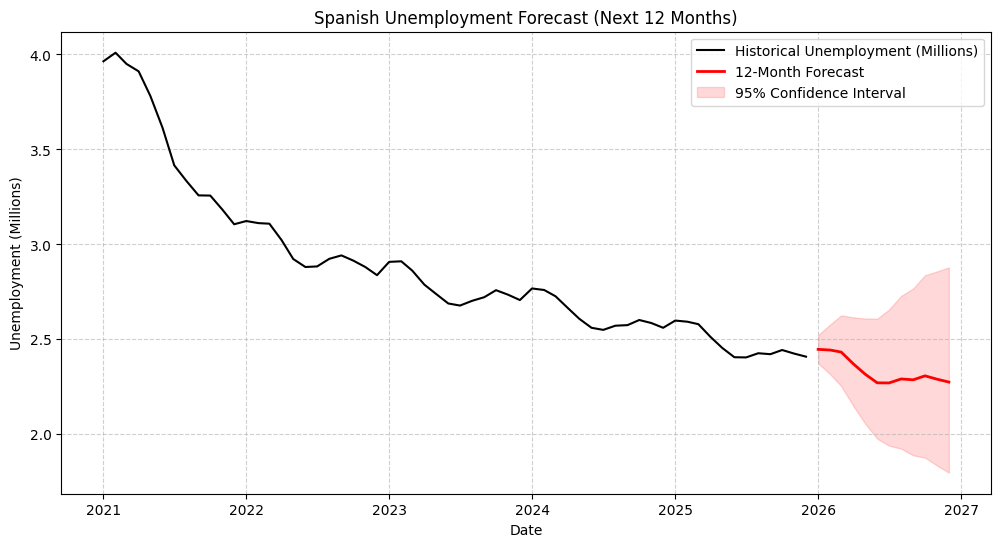

In [ ]:
# For the 12-month forecast, we'll input the log-transformed data directly into the SARIMAX function, rather than using the manually differenced (regular and seasonal) data from our earlier analysis.

# Python will handle the d=1 and D=1 differencing automatically during forecasting.
log_data = np.log(unemploy_millions)

# 2. Fit the three models to the ENTIRE dataset
# Model 1: ARIMA(1,1,0)
mod_1 = SARIMAX(log_data, order=(1, 1, 0), seasonal_order=(0, 1, 0, 12))
res_1 = mod_1.fit(disp=False)

# Model 2: SARIMA(1,1,0)(1,1,0)[12]
mod_2 = SARIMAX(log_data, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
res_2 = mod_2.fit(disp=False)

# Model 3: ARIMA(1,1,1)
mod_3 = SARIMAX(log_data, order=(1, 1, 1), seasonal_order=(0, 1, 0, 12))
res_3 = mod_3.fit(disp=False)

# 3. Print AIC and BIC to formally select the best model
print("--- Model Selection (Information Criteria) ---")
print(f"ARIMA(1,1,0)               -> AIC: {res_1.aic:.2f} | BIC: {res_1.bic:.2f}")
print(f"SARIMA(1,1,0)(1,1,0)[12]   -> AIC: {res_2.aic:.2f} | BIC: {res_2.bic:.2f}")
print(f"ARIMA(1,1,1)               -> AIC: {res_3.aic:.2f} | BIC: {res_3.bic:.2f}\n")

# Select Model 3 (ARIMA(1,1,1)) as the best based on earlier MAPE/RMSPE results and likely AIC
best_model = res_3
print("Selected Model: ARIMA(1,1,1)")

# 4. Generate forecasts and 95% confidence intervals for the next year (12 months)
forecast = best_model.get_forecast(steps=12)
pred_mean_log = forecast.predicted_mean
pred_ci_log = forecast.conf_int(alpha=0.05)

# 5. Reverse the log transformation to get forecasts in Millions of Unemployed
pred_mean = np.exp(pred_mean_log)
pred_ci = np.exp(pred_ci_log)

# 6. Plot the forecast against the historical data
plt.figure(figsize=(12, 6))

# Plot only the last 5 years of historical data for better visual clarity
history_plot = unemploy_millions.tail(60)
plt.plot(history_plot.index, history_plot, label='Historical Unemployment (Millions)', color='black')

# Plot the 12-month forecast and confidence intervals
plt.plot(pred_mean.index, pred_mean, label='12-Month Forecast', color='red', linewidth=2)
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color='red', alpha=0.15, label='95% Confidence Interval')

plt.title('Spanish Unemployment Forecast (Next 12 Months)')
plt.ylabel('Unemployment (Millions)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

While our preliminary out-of-sample evaluation indicated that the non-seasonal ARIMA(1,1,1) model provided marginally better point forecast accuracy in the hold out period, the Information Criteria evaluated on the full dataset favors the SARIMA(1,1,0)(1,1,0)[12] specification.  

The lower valude of our A. Information Criteria, suggest better goodness of fit of the model with the lowest level of compexity. under the AIC world a difference of more than 10 points is considered strong evidence. In our comparisons, the differece vs ARIMA(1,1,0) and ARIMA(1,1,1) is ´+65, means the model  is vastly superior at explaining the full dataset without over-fitting vs the other two models.


### Performance against loss functions (RMSE and MAPE)
As a sanity check, we complemented our AIC analysis by evaluating the models' in-sample performance against standard loss functions.

In [ ]:
# Function to calculate RMSE and MAPE
def calc_metrics(actual, predicted):
    # Ignore the first few NaN values caused by differencing lags
    mask = ~np.isnan(predicted) & (predicted > 0)
    y_true = actual[mask]
    y_pred = predicted[mask]

    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mape

# Extract fitted values and reverse log transformation (np.exp)
fit_1 = np.exp(res_1.fittedvalues)
fit_2 = np.exp(res_2.fittedvalues)
fit_3 = np.exp(res_3.fittedvalues)

# Calculate metrics against the actual historical data
rmse_1, mape_1 = calc_metrics(unemploy_millions, fit_1)
rmse_2, mape_2 = calc_metrics(unemploy_millions, fit_2)
rmse_3, mape_3 = calc_metrics(unemploy_millions, fit_3)

print("Historical Fit Metrics (In-Sample)")
print(f"ARIMA(1,1,0)               -> RMSE: {rmse_1:.4f} | MAPE: {mape_1:.2f}%")
print(f"SARIMA(1,1,0)(1,1,0)[12]   -> RMSE: {rmse_2:.4f} | MAPE: {mape_2:.2f}%")
print(f"ARIMA(1,1,1)               -> RMSE: {rmse_3:.4f} | MAPE: {mape_3:.2f}%\n")

Historical Fit Metrics (In-Sample)
ARIMA(1,1,0)               -> RMSE: 0.0917 | MAPE: 1.28%
SARIMA(1,1,0)(1,1,0)[12]   -> RMSE: 0.0881 | MAPE: 1.23%
ARIMA(1,1,1)               -> RMSE: 0.0916 | MAPE: 1.25%



The historical fit metrics confirm that the **SARIMA model minimizes both quadratic loss (RMSE: 0.0881) and absolute percentage loss (MAPE: 1.23%) when fitted to the entire series.**

However, it is crucial to emphasize that selecting the best relative model among these three does not imply the model perfectly captures the data generating process. As observed in earlier diagnostic checks, the models struggle with the assumption of normally distributed residuals. The Spanish unemployment series is inherently volatile and subject to severe structural economic shocks that linear ARIMA frameworks struggle to anticipate.

Therefore, while we select the SARIMA(1,1,0)(1,1,0)[12] to generate our 12-month forecast due to its superior handling of seasonal dynamics and lower information criteria, these projections must be interpreted with caution.

The forecast provides a mathematically sound baseline rooted in historical patterns, but the true 95% confidence intervals may be wider in reality due to the "fat-tailed" nature of macroeconomic shocks.